# **Recorridos en Profundidad**

## Ejercicio 1

Sea $T$ un árbol generador de un grafo (conexo) $G$ con raíz $r$, y sean $V$ y $W$ los vértices que están a distancia par e impar de $r$, respectivamente.

- $a)$ Observar que si existe una arista $vw \in E(G)\setminus E(T)$ tal que $v,w \in V$ o $v,w \in W$, entonces el único ciclo de $T \cup \{vw\}$ tiene longitud impar.

- $b)$ Observar también que si toda arista de $E(G) \setminus E(T)$ une un vértice de $V$ con otro de $W$, entonces $(V,W)$ es una bipartición de $G$ y, por lo tanto, $G$ es bipartito.

- $c)$ A partir de las observaciones anteriores, diseñar un algoritmo lineal para determinar si un grafo conexo $G$ es bipartito. En caso afirmativo, el algoritmo debe retornar una bipartición de $G$. En caso negativo, el algoritmo debe retornar un ciclo impar de $G$. Explicitar cómo es la implementación del algoritmo.

- $d)$ Generalizar el algoritmo del inciso anterior a grafos no necesariamente conexos observando que un grafo $G$ es bipartito si y solo si sus componentes conexas son bipartitas.

### **Solución a)**

Como $T$ es árbol, $T$ no tiene ciclos, pero si se le agrega una arista $e$ resulta un grafo con exactamente un ciclo, y ese ciclo contiene a $e$.

Luego, supongamos que $\exists \ vw \in E(G) \setminus E(T)$ tal que $v,w \in V$.

Es entonces que $T \cup \{vw\}$ tiene un ciclo $C$, y $\{vw \} \subset C$.

Nótese que, como $v,w \in T$ y $T$ es un árbol, existe un único camino $P$ en $T$ que vaya de $v$ hacia $w$. Luego, $P \subseteq (E(T) \cup \{vw\})$

Por otra parte, si llamo $Q = \{vw\}$ al camino de $T \cup \{vw\}$ que empieza en $v$ y termina en $w$; se tiene que $P \neq Q$ puesto que $vw \notin P \subseteq E(T)$; entonces $P$ y $Q$ forman un ciclo $C = P \sqcup \underbrace{\{wv\}}_{Q}$ que va de $v$ a $w$, y $\underbrace{Q  = \{vw\} = \{wv\}}_{\text{ pues grafo no dirigido}}$ está contenido en él.

Notar que como $v,w \in V$ se tiene que $I(P) = 2k$ para algún $k \in \mathbb{N}$; ya que:

- O bien el camino pasa por $r$, y luego si llamo $R_1, R_2$ al camino de $v$ a $r$ y el camino de $r$ a $w$ respectivamente, entonces $I(P) = I(R_1) + I(R_2) \ $ y como $I(R_1), I(R_2)$tienen misma paridad, $I(P)$ es par.

- O luego el camino no pasa por $r$, y entonces defino $z \in V(T)$ el vértice de menor nivel tal que el camino pasa por $z$. Entonces, pueden darse dos situaciones:

  - $z = v \ \lor \ z = w $; (SPG, $z = v$) y por lo tanto $R_1 \subseteq R_2$, con $R_2 = R_1 \sqcup P$;  y entonces $I(R_2)= I(R_1) + I(P)$ y como $I(R_1), I(R_2)$ tienen misma paridad, entonces $I(P)$ es par.

  - $z \neq v \ \land \ z \neq w $. Luego, si llamo $Z_1, Z_2$ al camino de $v$ a $z$ (o de $z$ a $v$), y de $z$ a $w$ (o de $w$ a $z$) respectivamente, entonces $Z_1 \subset R_1$ y $Z_2 \subset R_2$ (pues caminos únicos, entonces como el nivel de $z$ es menor al de $v, w$; entonces el camino que va hacia $v$ o $w$ debe necesariamente pasar por $z$; pues de lo contrario, habrían más de un camino, lo cual contradice que $T$ sea un árbol). Llamemos $RZ$ al camino entre $r$ y $z$.

    Veamos caso $v, w \in V$ (caso $v,w \in W$ es análogo en procedimiento)

    Entonces si $I(Z_1)$ es un número impar, entonces como $I(R_1) = I(Z_1) + I(RZ)$ entonces eso implica que $I(RZ)$ es impar (pues $I(R_1)$ par). Finalmente, al tener que $I(R_2) = I(Z_2) + I(RZ)$, se tiene que $I(Z_2)$ es impar también. Por lo tanto, $I(P) = I(Z_1) + I(Z_2)$ es un número par.

    Y si $I(Z_1)$ es par, con un desarrollo análogo se tiene que $I(Z_2)$ es par; y luego $I(P)$ es par

$ $

Luego, como $I(P)$ es par, entonces $I(C) = I(P) + 1$ es impar como se quería probar; y $\{vw\} \subset C$.

$\hspace{24cm} \huge\boxtimes$


### **Solución b)**

Notar que $V \cup W = V(T), \ \ V \cap W = \emptyset$ ya que $T$ árbol generador de $G$ y la paridad es única.

Por un lado, tengo que $\forall (p,q) \in E(T)$, se tiene que $p \in V \ \land \ q \in W$ (o, análogamente, $q \in V \ \land \ p \in W$); puesto que no existen aristas entre vértices de un mismo nivel, ni entre niveles no consecuentes (pues $T$ árbol; y luego $\forall (p,q) \in E(T)$ se tiene que $|d(r,p) - d(r,q)| = 1 \ $ y luego presentan distinta paridad). Y para todo nodo de $V(G)$ existe una arista en $T$ (pues $G$ conexo).

Y, dado que $E(G) = E(G) \setminus E(T) \sqcup E(T)$ y se tiene que toda arista de $E(G) \setminus E(T)$ une un vértice de $V$ con otro de $W$; en conjunto se tiene que para todo $v \in V, \ (v,u) \in E(G) \Rightarrow u \in W$ y de forma análoga para $W$.

Luego, $(V,W)$ es una partición bipartita de $G$ y, por lo tanto, $G$ es bipartito.

$\hspace{25cm} \huge\boxtimes$

### **Solución c)**

SPG, tomo que $V(G) = \{0,..., |V(G|-1 \}$


$1)$ Utilizando DFS, defino las variables $pred$ y $distancias\_a\_raiz$, donde $pred[i] = $ padre de la arista $i$, con la raíz igual a $r = 0$; y $distancias\_a\_raiz[i] = d(r,i) = d(r, pred[i]) + 1$

$2)$ Defino el vector $D$ donde $D[i] \in \{ $'$par$'$, $ '$impar$'$ \}$ en función de la paridad de $distancias\_a\_raiz[i]$.

$3)$ Recorro $E(G)$:

- Si $ \forall (v,w) \in E(G)$, $D[v] \neq D[w]$ entonces devuelvo $V, W$ donde $V = \{i : D[i] = \ $ '$par$'$ \}, \ W = \{ i : D[i] = \ $'$impar$'$ \}$.

- Caso contrario, si $\exists (v,w) \in E$ tal que $D[v] = D[w]$; entonces tomo el vértice que presenta una mayor distancia a la raíz (SPG, tomo que es $w$) y defino $C = \{ (w_i, w_{i+1}): 0 \leq i < m \} \cup \{(v,w)\} \quad$ con $w_0 = w$, $w_{i+1} = pred[w_i]$ y $w_m = pred[w_{m-1}] = v$


$ \ $

Analicemos la complejidad del algoritmo.

En primer lugar, el paso $1)$ presenta un costo conocido de $O(|V(G)| + |E(G)|)$, pues es recorrer el grafo $G$ en profundidad (DFS).

En el paso $2)$, la creación del vector y la asignación de la paridad tiene un costo $O(|V|)$.

Por último, en el peor de los casos, tuve que haber recorrido todas las aristas de todos los vértices de $G$ para hallar que existe un $backedge$ entre nodos de misma paridad en cuanto a su distancia con la raíz, y por lo tanto debo recorrer a lo sumo todos los vértices del grafo nuevamente mediante la observación de los ancestros. Esto tomaria entonces $O(|V| + |E|)$.

$ \ $

En conclusión, se cuenta con una complejidad temporal lineal $O(|V| + |E|)$.

In [ ]:
def recorrer(G):
    #Devuelvo las variables pred y distancias_a_raiz
    #pred[i] = padre de i
    #distancias_a_raiz[i] = d(r,i) donde r = raiz = 0
    r = 0
    pred = [0 for _ in range(len(G))]
    distancias_a_raiz = [-1 for _ in range(len(G))]
    distancias_a_raiz[r] = 0

    #Algoritmo DFS
    pila = deque()
    pila.append(r)
    while len(pila) != 0:
        i = pila[-1]
        hay_vecino_no_visitado = False
        for j in G[i]:
            if distancias_a_raiz[j] == -1:
                pred[j] = i
                distancias_a_raiz[j] = distancias_a_raiz[i] + 1
                pila.append(j)
                hay_vecino_no_visitado = True
                break

        if not hay_vecino_no_visitado:
            pila.pop()

    return pred, distancias_a_raiz


def esBipartito(G):
    #Si el grafo G es bipartito, devuelvo una bipartición V,W
    #Caso contrario, devuelvo un ciclo C

    #Utilizando DFS, consigo las variables pred y distancias_a_raiz
    #pred[i] = padre de i
    #distancias_a_raiz(i) = d(r,i) donde r = raiz = 0
    pred, distancias_a_raiz = recorrer(G)

    #Defino el vector D donde D[i] = 0 si d(r,i) es par; y 1 en caso contrario
    D = [0 for _ in range(len(G))]

    for i in range(len(G)):
        if distancias_a_raiz[i] % 2 != 0:
            D[i] = 1


    #Recorro E(G)
    for i in range(len(G)):
        #Mi intención es, si no se encuentra un arco (i,j) con D[i] = D[j], devolver V y W
        #Caso contrario, devuelvo un ciclo
        for j in G[i]:
            if D[i] != D[j]:
                continue

            else: #Grafo no bipartito, pues hallé arco entre vértices de misma paridad en su distancia a r
                v = i
                w = j
                #Debo identificar cuál de los dos es un ancestro del otro
                #Para ello, observo sus distancias a con la raíz.
                #El vértice de menor distancia a con la raíz, es el ancestro.
                #En ambos casos, defino C el ciclo (conjunto de aristas)
                C = list()

                if distancias_a_raiz[v] <= distancias_a_raiz[w]: #caso v es el ancestro
                    actual = w
                    while actual != v:
                        C.append((actual, pred[actual]))
                        actual = pred[actual]

                    C.append((v,w))
                    return C

                else: #caso w es el ancestro
                    actual = v
                    while actual != w:
                        C.append((actual, pred[actual]))
                        actual = pred[actual]

                    C.append((w, v))
                    return C

    #¡El grafo es bipartito!

    V = [i for i in range(len(D)) if D[i] == 0]
    W = [i for i in range(len(D)) if D[i] == 1]
    return V, W

### **Solución d)**

Las modificaciones a hacer para que funcione en grafos no conexos se basan en agregar, como primer paso, hallar las componentes conexas de nuestro grafo $G$, para luego realizar el procedimiento en cada una de ellas; y definir una de las biparticiones como la unión de una de las biparticiones de cada componente conexa (y luego, la otra es su complemento).

$ \ $

En definitiva, el algoritmo es el siguiente:

$1)$ Aplicando el algoritmo de DFS, obtengo el conjunto de las componentes conexas de $G$. Defino $V$ y $W$ y luego, para cada componente conexa $\tilde{G}$, aplico el algoritmo anterior tomando un vértice cualquiera de la componente como raíz:

- Si $\tilde{G}$ no es bipartito, retorno el ciclo $\tilde{C}$ del grafo, finalizando el procedimiento.

- Si lo es, entonces una de las biparticiones la agrego a $V$ y la otra a $W$

$2)$ Si todas las componentes conexas son bipartitas (es decir, no hubo retorno de ningún ciclo), devuelvo $V, W$.

In [ ]:
def recorrer(G, r, pred, distancias_a_raiz):
    #Devuelvo las variables pred y distancias_a_raiz
    #pred[i] = padre de i
    #distancias_a_raiz[i] = d(r,i) donde r = raiz = 0
    distancias_a_raiz[r] = 0

    #Algoritmo DFS
    pila = deque()
    pila.append(r)
    while len(pila) != 0:
        i = pila[-1]
        hay_vecino_no_visitado = False
        for j in G[i]:
            if distancias_a_raiz[j] == -1:
                pred[j] = i
                distancias_a_raiz[j] = distancias_a_raiz[i] + 1
                pila.append(j)
                hay_vecino_no_visitado = True
                break

        if not hay_vecino_no_visitado:
            pila.pop()



def esBipartito(G):
    #Si el grafo G es bipartito, devuelvo una bipartición V,W
    #Caso contrario, devuelvo un ciclo C

    #Utilizando DFS, consigo las variables pred y distancias_a_raiz
    #pred[i] = padre de i
    #distancias_a_raiz(i) = d(r,i) donde r = raiz

    #Defino el vector D donde D[i] = 0 si d(r,i) es par; y 1 en caso contrario
    D = [0 for i in range(len(G))]
    r = 0
    pred = [0 for _ in range(len(G))]
    distancias_a_raiz = [-1 for _ in range(len(G))]

    #Analizo cada componente conexa
    for r in range (len(G)):
        if distancias_a_raiz[r] == -1:
            recorrer(G, r, pred, distancias_a_raiz)


    #Una vez recorrido cada vértice, defino las paridades
    for i in range(len(G)):
        if distancias_a_raiz[i] % 2 != 0:
            D[i] = 1

    #Recorro E(G)
    for i in range(len(G)):
        #Mi intención es, si no se encuentra un arco (i,j) con D[i] = D[j], devolver V y W
        #Caso contrario, devuelvo un ciclo
        for j in G[i]:
            if D[i] != D[j]:
                continue

            else: #Grafo no bipartito, pues hallé arco entre vértices de misma paridad en su distancia a r
                v = i
                w = j
                #Debo identificar cuál de los dos es un ancestro del otro
                #Para ello, observo sus distancias a con la raíz.
                #El vértice de menor distancia a con la raíz, es el ancestro.
                #En ambos casos, defino C el ciclo (conjunto de aristas)
                C = list()

                if distancias_a_raiz[v] <= distancias_a_raiz[w]: #caso v es el ancestro
                    actual = w
                    while actual != v:
                        C.append((actual, pred[actual]))
                        actual = pred[actual]

                    C.append((v,w))
                    return C

                else: #caso w es el ancestro
                    actual = v
                    while actual != w:
                        C.append((actual, pred[actual]))
                        actual = pred[actual]

                    C.append((w, v))
                    return C

    #¡El grafo es bipartito!

    V = [i for i in range(len(D)) if D[i] == 0]
    W = [i for i in range(len(D)) if D[i] == 1]
    return V, W



## Ejercicio 2

Una arista de un grafo $G$ es puente si su remoción aumenta la cantidad de componentes conexas de $G$. Sea $T$ un árbol DFS de un grafo conexo $G$.

- $a)$ Demostrar que $vw$ es un puente de $G$ si y solo si $vw$ no pertenece a ningún ciclo de $G$.

- $b)$ Demostrar que si $vw \in E(G) \setminus E(T)$, entonces $v$ es un ancestro de $w$ en $T$ o viceversa.

- $c)$ Sea $vw \in E(G)$ una arista tal que el nivel de $v$ en $T$ es menor o igual al nivel de $w$ en $T$. Demostrar que $vw$ es puente si y solo si $v$ es el padre de $w$ en $T$ y ninguna arista de $G \setminus \{vw\}$ une a un descendiente de $w$ (o a $w$) con un ancestro de $v$ (o con $v$).

- $d)$ Dar un algoritmo lineal basado en DFS para encontrar todas las aristas puente de $G$. Ayuda: el algoritmo puede hacer un uso inteligente de un único DFS. Conceptualmente, y a los efectos de este ejercicio, puede convenir separar el algoritmo en dos fases. La primera fase aplica DFS para calcular el mínimo nivel que se puede alcanzar desde cada vértice usando back edges que estén en su subárbol. La segunda fase recorre todas las aristas (sin DFS) para chequear la condición.

### **Solución a)**

Probemos la doble implicación:

$ \ $

$\Rightarrow)$ Demostremos el contrarrecíproco: si $vw$ arista de $G$ tal que $vw \in C$ con $C$ ciclo de $G$, entonces $vw$ no es una arista puente.

Supóngase que $\exists vw \in E(G)$ una arista de $G$ tal que $vw \in C$ con $C$ un ciclo de $G$. Para simplificar el razonamiento (y dado que para cualquier vértice que conforma $C$ se puede pensar que es el inicio/final del ciclo), entonces tomaremos que éste tiene la forma:

$\hspace{5cm} w \rightarrow c_1 \rightarrow \ ... \rightarrow c_n \rightarrow v \rightarrow w$

Luego, sean $u, z \in V(G)$. Veamos que si existe camino entre $u$ y $z$, entonces si tomo el grafo inducido por $G \setminus \{vw\}$, entonces sigue habiendo camino entre $u$ y $z$ (y, por lo tanto, no aumenta la cantidad de componentes conexas).

Notar que si no existe camino entre $u$ y $z$ (es decir, $G$ no es conexo), entonces es claro que tampoco existirá camino entre ellos en $G \setminus \{vw\}$. Sin embargo, este hecho no implica el aumento de componentes conexas (sino la persistencia de las originales).

Es entonces que si existe camino entre mis vértices, llámese $P$, es claro que si $vw \notin P$, entonces $P \subseteq E(G \setminus \{vw\})$ (es decir, continúa habiendo camino entre $u$ y $z$).

Por otro lado, si $vw \in P$, entonces si tomo $P = \{p_1,...,p_m \}$ donde $p_m = uz \ $ y $p_1 = uq$ para algún $q \in V(G)$, y luego $p_k = vw$, entonces puedo definir:

$\tilde{P} = \{ p_1,...,p_{k-1}, \underbrace{vc_n, ..., c_1w}_{v \rightarrow ... \rightarrow w},p_{k+1},...,p_{m} \}$

Si $\tilde{P}$ es camino ya gané. Si no es camino, simplemente es necesario eliminar aristas extra para que no hayan vértices repetidos (el haber podido encontrar un recorrido entre $u$ y $z$ me asegura la existencia de un camino entre ambos).

En definitiva, $\forall u, v \in V(G),$ si $\exists P$ camino entre $u$, $z \ \Rightarrow \ \exists \tilde{P}$ camino entre $u$, $z$ en el grafo inducido por $G \setminus \{vw \}$.

Por lo tanto, $G$ y $G \setminus \{vw\}$ tienen la misma cantidad de componentes conexas. Por lo tanto, $\{vw\}$ no es una arista puente.

$\therefore $ Si $vw$ es una arista puente de $G$, $vw$ no pertenece a ningún ciclo del grafo. $\quad \checkmark$

$ \ $

$\Leftarrow)$ Nuevamente probemos el contrarrecíproco: si $vw$ no es una arista puente de $G$, entonces $vw$ pertenece a un ciclo de $G$.

Sea entonces $vw$ una arista de $G$ tal que el grafo inducido por $G \setminus \{ vw \}$ no presenta más componentes conexas que $G$.

Eso quiere decir que si tomo $P = \{vw \}$ el camino entre $v$ y $w$, entonces yo sé que existe $\tilde{P}$ camino entre $w$ y $v$ tal que $\tilde{P} \neq P$. Esto es pues, como $vw$ no es una arista puente, y existe camino entre $w$ y $v$ en $G$, entonces existe camino entre ellos en $G \setminus \{vw\}$ (que involucra por lo tanto al menos un vértice distinto a los analizados, pues $\tilde{P} \subseteq G \setminus \{vw \}$ y $ \{vw\} \nsubseteq G \setminus \{vw\}$).

Luego, $P \cup \tilde{P}$ forma un ciclo (pues en $P$, se tiene $v \rightarrow w$ y en $\tilde{P}$, $w \rightarrow \tilde{p} \rightarrow \ ... \ \rightarrow v$, y se obtiene un recorrido de más de tres vértices que empieza y termina en $v$).

Y como $vw$ es una arista no puente de $G$ cualquiera y $vw$ pertenece a un ciclo del grafo, entonces toda arista no puente de $G$ pertenece a un ciclo del mismo.

$\therefore $ Si $vw$ es arista de un grafo $G$ que no pertenece a ningún ciclo del grafo, entonces $vw$ es una arista puente de $G$. $\quad \checkmark$


$ \ $

$\hspace{23cm} \huge\boxtimes$

### **Solución b)**

Nótese que, utilizando el algoritmo DFS, se recorre cada vértice uno a la vez.

Es decir que necesariamente uno será "descubierto" antes que el otro. SPG, supongamos que el primero en ser descubierto es $v$.

Luego, a partir de $v$, se empieza a recorrer en profundidad toda su _descendencia_. Y como $vw \in E(G) \setminus E(T)$, entonces $w$ es descubierto a partir de una arista distinta a $vw$ (de lo contrario, si $w$ descubierto por esa arista, entonces $vw \in E(T) \ $ y $ \ pred[w] = v$).

Si desarrollamos la cadena de vértices recorridos en el orden inverso al que fueron encontrados se alcanza la (única, pues $G$ conexo) raíz $r$ (el primer nodo visto). Nótese que, en el algoritmo DFS, antes de poder "subir/retroceder", se deben haber recorrido todas las aristas incidentes al vértice actual. Es decir, tras descubrir $v$, la exploración de su vecindad no finalizará hasta que se hayan descubierto todos los vértices alcanzables desde $v$.

Es decir, dado que $orden(w) > orden(v)$ y $vw \in E(G)$ (es decir que $w$ es alcanzable a partir de $v$), entonces el algoritmo descubre a $w$ antes de finalizar la exploración de la descendencia de $v$; y luego $v$ es ancestro de $w$.


$\hspace{23cm} \huge\boxtimes$

### **Solución c)**

Probemos la doble implicación

$ \ $

$\Rightarrow)$ Como $vw$ es una arista puente, eso quiere decir que no existe camino entre $v$ y $w$ en el grafo inducido por $G \setminus \{vw\}$.

Luego, si existiera una arista en $E(G \setminus \{vw\})$ que una a un ancestro de $v$ (o a $v$) con un descendiente de $w$ (o $w$), entonces se llegaría a la existencia de un camino entre $v$ y $w$ en $G \setminus \{vw\}$.

Esto es pues si llamamos $z,u \in V(G)$ tal que $z$ ancestro de $v$ (o el mismo $v$) y $u$ descendiente de $w$ (o el mismo $w$) entonces tengo el camino $P_{v-z}$ que une a $v$ con $z$ (que existe pues $z$ ancestro; o luego simplemente hablamos del mismo nodo), $P_{z-u}$ el de $z$ a $u$, y $P_{u-w}$ el camino de $u$ a $w$ (que existe pues $u$ descendiente, o en cambio nos referimos al mismo nodo).

Entonces $P = P_{v-z} \cup P_{z-u} \cup P_{u-w}$ es camino entre $v$ y $w$, donde $P \subseteq E(G \setminus \{vw\}) \quad ABS$


Y, por otro lado, esto implica que como el nivel de $w$ es menor o igual al nivel de $v$, entonces como $vw \in E(G)$, $v$ es el padre de $w$ en el árbol $T$, ya que de lo contrario existiría un camino que une a $v$ y $w$ (pues $T$ árbol, por ende conexo; y $vw \notin E(T)$) y entonces $vw$ no es una arista puente. $\quad ABS$

$\therefore$ Si $vw$ arista puente, $v$ es padre de $w$ y ninguna arista de $G \setminus \{vw\}$ une a un descendiente de $w$ (o a $w$) con un ancestro de $v$ (o con $v$).

$ \ $

$\Leftarrow )$ Yo sé que $v$ es el padre de $w$ en $T$ y ninguna arista de $G \setminus \{vw\}$ une a un descendiente de $w$ (o a $w$) con un ancestro de $v$ (o con $v$).

Notar que, como $v$ es padre de $w$, y $T$ es un árbol generador de $G$ calculado a partir de un algoritmo DFS, eso implica que no existe arista $yx \in E(G) \setminus E(T)$ con $y$ descendiente de $w$ (o $w$) tal que:

- Nivel de $x \geq$ Nivel de $v \ $ pero $v$ no es ancestro de $x$ (o el mismo $v$).

  - Esto es pues por inciso $b)$, como $yx \in E(G) \setminus E(T)$ o bien $x$ es desdenciente de $y$ o $y$ desciende de $x$. Pero si $x$ desciende de $y$, entonces por transitividad desciende también de $w$ y, luego, de $v$; y si $y$ desciende de $x$, entonces algún ancestro de $y$ (o el mismo $y$) tiene más de un padre (lo cual es $ABS$ pues $T$ árbol). De lo contrario, si todos tienen un único padre, entonces como $y$ desciende de $v$, entonces $x$ también, ya que si tomamos $T_v$ la subrama del árbol que tiene a $v$ como raíz, si $x$ está a un nivel inferior, no tiene más de un padre y es ancestro de $y$, entonces $x \in T_v$ (pues $v$ ancestro de $y$), y si $x$ está al mismo nivel que $v$, entonces para que $y$ sea su desdendiente, debe ocurrir que $w$ sea su hijo, y luego $v = x$.

- Nivel de $x < $ Nivel de $v \ $ pero $v$ no es descendiente de $x$.

  - Esto se debe a que por inciso $b)$, $x$ es ancestro de $y$ o viceversa. Luego, si $y$ es ancestro de $x$, entonces $ \ $ nivel de $x <$ nivel de $y <$ nivel de $v <$  nivel de $x \ \ ABS$; y, por otro lado, si $x$ es ancestro de $y$, si tomo $P_{y-x}$ el camino de $y$ a $x$ en $T \ $ (notar $P_{y-x} \subseteq P_{y-r}$) entonces como $y$ desciende de $v$, el cual está a un nivel inferior entonces $P_{y-x} = P_{y-v} \cup P_{v-x}$ y luego $v$ desciende de $x$ (ya que $P_{v-x} \subseteq P_{x-r}$; pues sino como $P_{y-r} = P_{y-v} \cup P_{v-r}$ y es claro que $P_{v-x} \nsubseteq P_{y-v}$ entonces $P_{v-x} \subseteq P_{v-r}$; lo que significa que para ir de $v$ a la raíz, es necesario pasar por $x$, por lo que $x$ es ancestro de $v$).

$ \ $

Es por eso que si existiera camino entre $v$ y $w$ en $G \setminus \{vw\}$, entonces la única forma es que exista arista entre un ancestro de $v$ (o $v$) y un descendiente de $w$ (o $w$). Lo cual, por hipótesis, es absurdo.

Por lo tanto, como no existe camino entre $v$ y $w$, entonces $G \setminus \{vw\}$ no es conexo, y luego la cantidad de componentes conexas aumenta tras la remoción de la arista $vw$. Se desprende entonces que la arista $vw$ es puente.


$\hspace{24cm} \huge\boxtimes$

### **Solución d)**

SPG, tomo $V(G) = \{0,1,...,|V(G)|-1 \}$

$1)$ Utilizar DFS para recorrer el árbol (tomando raíz $r = 0$, pues grafo conexo entonces es indistinto el nodo con el que se arranca). En el mismo, defino las variables $nivel$ donde $nivel[i] =$ nivel del nodo $i$ ($nivel[r] = 0$); $pred$ donde $pred[i] = $ padre de $i$ ($pred[r] = None$); $min\_nivel\_alcanza$ tal que $min\_nivel\_alcanza[i] = $ mínimo nivel que se puede alcanzar desde $i$ usando back edges ($min\_nivel\_alcanza[r] = 0$); y $descubierto$ el cual $descubierto[i] = True$ solo si $i$ fue añadido a la pila del algoritmo (en principio, todos inicializados con $False$ excepto $r$).



$2)$ Mientras la pila no esté vacía, miro el tope de la misma, llamémoslo $i$, y:

- Si $i$ tiene algún vecino $j$ (alguna arista $ij$) sin procesar:.

  - Si $Descubierto[j]$ es $True$ y si $j \neq pred[i]$ y $nivel[j] < nivel[i]$, entonces:

    - $min\_nivel\_alcanza[i] = min \{ min\_nivel\_alcanza[i], nivel[j] \}$
  
  - Si $Descubierto[j]$ es $False$, entonces:

    - $pred[j] = i$

      $nivel[j] = nivel[i] + 1$

      $min\\_nivel\\_alcanza[j] = nivel[j]$

      $descubierto[j] = True$

      Agrego $j$ a la pila

- Si a $i$ no le quedan vecinos:

  - Si $pred[i] \neq None$:

    - $min\_nivel\_alcanza[pred[i]] = min \{min\_nivel\_alcanza[pred[i]], min\_nivel\_alcanza[i]\}$

  - Saco a $i$ de la pila.

$3)$ Recorro las variables $nivel$ y $min\_nivel\_alcanza$ (arrancando desde el vértice $i=1$). Si $nivel[i] == min\_nivel\_alcanza[i]$, entonces $pred[i]  i$ es una arista puente (se la puede adicionar a una lista o agregar un contador que vaya registrando la cantidad observada).


Como los pasos $1), 2)$ son propios del algoritmo DFS (con inicialización de variables de tamaño $|V(G)|$), se tiene una complejidad $O(|V(G)| + |E(G)|)$. Por último, el paso $3)$ presenta un costo temporal $O(|V(G)|)$ pues es recorrer un arreglo del tamaño de la cantidad de vértices, y realizar operaciones $O(1)$ (si se crea una lista, entonces bajo un análisis amortizado, el costo de agregar un nuevo elemento sigue esa complejidad).

En definitiva, la complejidad final del algoritmo es lineal $O(|V(G)| + |E(G)|)$.

# **Recorridos en Anchura**

## Ejercicio 5

Un árbol generador $T$ de un grafo $G$ es $v$-geodésico si la distancia entre $v$ y $w$ en $T$ es igual a la distancia entre $v$ y $w$ en $G$ para todo $w \in V(G)$. Demostrar que todo árbol BFS de $G$ enraizado en $v$ es $v$-geodésico. Dar un contraejemplo para la vuelta, i.e., mostrar un árbol generador $v$-geodésico de un grafo $G$ que no pueda ser obtenido cuando BFS se ejecuta en $G$ desde $v$.

### **Solución**

Sea $v \in V(G)$ arbitrario.

Y sea luego $T$ el árbol BFS de $G$ enraizado en $v$ (o sea, $raiz_T = v$).

Sea entonces $w \in V(G)$.

Si no existe camino entre $v$ y $w$ en $G$, entonces $d_T(v, w) = d_G(v,w) = \infty$ puesto que BFS no genera nuevas aristas, sino que recorre las de $G$ (y es claro que no hay subconjunto de ellas que conecte a $v$ y $w$, pues de lo contrario existiría un camino).

Supongamos ahora que sí existe camino entre $v$ y $w$. Llamemos luego $P = \{ p_0, p_1,...,p_n\} \subseteq V(G)$ a la secuencia de vértices que describe el _camino mínimo_ entre $v$ y $w$. Es decir que $p_0 = v$, $p_n = w \ $ y $ \ p_ip_{i+1} \in E(G) \ \forall 0 \leq i < n$. Esto quiere decir que $d(v, w) = n$.

Luego, como $vp_1 \in E(G)$, y dado que $T$ es el árbol BFS enraizado en $v$, entonces $d(v,p_1) = 1$, puesto que como $v$ es la raíz, entonces el algoritmo recorre primero su vecindario y asigna como $1$ a la distancia de sus vecinos a consigo mismo.

Ahora bien, es importante notar lo siguiente: como $P$ es camino mínimo, entonces $vp_j \notin E(G) \ \forall 2 \leq j < n$. De lo contrario, si tomo $\tilde{P} = \{v, p_j, p_{j+1}, ... , p_n\}$ entonces $\tilde{P}$ es recorrido e $I(\tilde{P}) < I(P) \ \ ABS$ pues $P$ camino mínimo. De la misma forma, $p_1p_j \notin E(G) \ \forall 3 \leq j < n$, pues de lo contrario se llega al mismo absurdo. De manera sucesiva para el resto, podemos luego declarar que $p_i p_j \notin E(G) \ \forall 0 \leq i < n-1 \ \ \land  \ \ i+1 < j < n$

Entonces, en particular $p_2$ no es vecino de $v$, por lo que $d_G(v, p_2) > 1$, y el algoritmo designa $d_T(v, p_2) > 1$. Y luego, como sí lo es de $p_1$, entonces necesariamente $d_G(v, p_2) = 2$ y, por otra parte, $d_T(v, p_2) \leq 2$ (y entonces $d_T(v, p_2) = 2$), puesto que o bien $d_T(p_1, p_2) = 1$ (y luego $d_T(v, p_2) = d_T(v, p_1) + d_T(p_1, p_2) = 2$), o luego existe $\tilde{v}$ vecino de $v$ tal que $\tilde{v}p_2 \in E(G)$ y $d_T(\tilde{v}, p_2) = 1$, obteniendo que $d_T(v, p_2) = d_T(v, \tilde{v}) + d_T(\tilde{v}, p_2) = 2 = d_G(v, p_2)$ (después de recorrer a los vecinos de $v$ para asignarles distancia $1$, BFS recorre el vecindario de estos vecinos para asignarles distancia $2$ de $v$).

Por otro lado, notar que $\tilde{v}p_3 \notin E(G) \ \forall \tilde{v} \in N(v)$, puesto que de lo contrario $\tilde{P} = \{v, \tilde{v}, p_3, p_4,...,w\}$ es un recorrido entre $v$ y $w$ con $I(\tilde{P}) < I(P) \ \ ABS$.

Luego, $d_G(v) = 3$ (puesto que $P = \{v, p_1, p_2, p_3 \}$ representa un camino mínimo entre $v$ y $p_3$). Y, por otro lado, como $p_3$ no pertenece al vecindario de ningún vecino de $v$, entonces $d_T(v, p_3) > 3$, y como sí pertenece al vecindario de un vecino del vecindario de $v$, entonces $d_T(v, p_3) \leq 3$ (puesto que, o bien $d_T(p_2, p_3) = 1$ y entonces $d_T(v,p_3) = d_T(v, p_2) + d_T(p_2, p_3) = 3$ o luego existe $\tilde{\tilde{v}} \in \{N(\tilde{v}) : \tilde{v} \in N(v) \}$ tal que $d_T(\tilde{\tilde{v}}, p_3) = 1$ (o sea, $\tilde{\tilde{v}} p_3 \in E(G)$ y los vecinos de $\tilde{\tilde{v}}$ son revisados antes que los de $p_2$ por el algoritmo) y entonces $d_T(v, p_3) = d_T(v, \tilde{\tilde{v}}) + d_T(\tilde{\tilde{v}}, p_3) = 3$.

De manera sucesiva, se consigue que $d_T(v, \underbrace{w}_{p_n}) = n = d_G(v,w). \quad \checkmark$

$ \ $

Y dado que $w \in V(G)$ era cualquiera, entonces $\forall w \in V(G)$ se tiene que $d_T(v,w) = d_G(v,w)$. Por lo tanto, $T$ es $v$-geodésico.

Finalmente, como $v \in V(G)$ era arbitrario, entonces para todo $v \in V(G)$, luego $T$ el árbol BFS de $G$ enraizado en $v$ es $v$-geodésico.


$\hspace{23cm} \huge\boxtimes$





Ahora bien, veamos que no vale la vuelta observando el siguiente ejemplo:

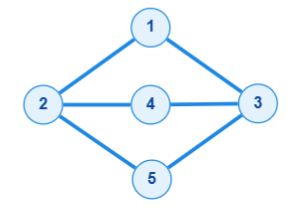

In [ ]:
from IPython.display import Image
Image(filename="/content/grafo_ejemplo.png")


A partir del mismo, es posible plantear el siguiente árbol $1$-geodésico

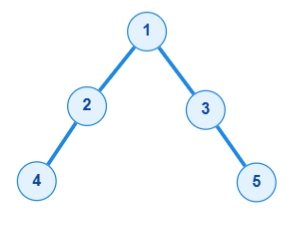

In [ ]:
Image(filename="/content/arbol_1_geodesico.png")

Sin embargo, no es posible obtenerlo con BFS. ¿Por qué?

Puesto que, si tomo como raíz al $1$, entonces el algoritmo empieza tomando asignando como sus _hijos_ al $2$ y $3$.

Luego, nótese que tanto el $2$ como el $3$ están conectados al $4$ y $5$. Sin embargo, el algoritmo tomará uno de los nodos (ya sea el $2$ y el $3$) y revisará _todas_ sus conexiones (aparte del padre) y las asignará como sus hijos.

Por lo tanto, ya sea si es procesado primero el vecindario de $2$ o $3$, no es posible "separar" a los nodos $4$ y $5$ para asignarlos a distintos padres.

$ $

Y luego, no todo árbol $v$-geodésico de un árbol generador $T$ de un grafo $G$ puede ser obtenerse mediante BFS.

## Ejercicio 8

Se tiene una grilla con $m \times n$ posiciones, cada una de las cuales tiene un número entero en $[0, k)$, para un $k \in \mathbb{N}$ dado. Dado un valor objetivo $w \in \mathbb{N}$ y una posición inicial $(x_1,y_1)$, que tiene un valor inicial $v_1$, queremos determinar la mínima cantidad de movimientos horizontales y verticales que transformen $v_1$ en $w$, teniendo en cuenta que el $i$-ésimo movimiento transforma a $v_i$ por $v_{i+1} = (v_i +z) \ mod \ k$, donde $z$ es el valor que se encuentra en la casilla de destino del movimiento. Por ejemplo, para la siguiente grilla y $k = 10$, se puede transformar $v_1 = 1$ en $w = 0$
con tres movimientos $1 \rightarrow 6 \rightarrow 4 \rightarrow 9$, aunque la solución óptima es vía el camino $1 \rightarrow 3 \rightarrow 6$.

$$
\begin{array}{|c|c|c|}
\hline
1 & 3 & 6 \\
\hline
6 & 7 & 4 \\
\hline
4 & 9 & 3 \\
\hline
\end{array}
$$

Modelar este problema como un problema de grafos que se resuelva usando BFS en $O(kmn)$ tiempo.


### **Solución**

Llamemos $M \in \mathbb{N}^{m \times n}$ la matriz del problema. Es claro que el primer paso es generar el grafo $G$.

Esto se puede hacer tomando como $V(G) = M$. Es decir, los vértices del grafo son los valores de las casillas de la matriz.

Y, por otro lado, $E(G) = \{M_{ij}M_{(i+1) \ j} : 0 \leq i < m-1  \ \land \ 0 \leq j < n \} \ \cup \ \{M_{ij}M_{i \ (j+1)} : 0 \leq i < m \ \land \ 0 \leq j < n-1 \} $

Esto se puede lograr en $O(nm)$ pues es crear un vector $E(G)$ de tamaño menor a $4 \times m \times n$ (porque como máximo un casillero en una matriz tiene cuatro casillas adyacentes) en donde guardar las aristas (y para $V$ a lo sumo realizo una copia de $M$ en $O(nm)$).


Luego, puedo modelar $G$ como una _lista de adyacencia_ en $O(m + n)$, para poder usarlo para BFS.

A partir de ahora, ya tomamos $G$ como el grafo que describe la situación inicial.

Diseño así el siguiente algoritmo para el caso $w < k$:

$1)$ Aplico BFS para empezar el recorrido a partir $nodo\_actual = V(G)_{(x, y)}$.

$2)$ - Si para algún $j \in N(nodo\_actual)$ se tiene que $(nodo\_actual + j) \ mod \ k = w$ entonces devuelvo

Notar que, si llamamos $M$ a la mariz del problema, la cantidad de estados posibles que existen son $k \times m \times n$, puesto que $a \ mod \ k$ puede tomar un valor entero entre $0$ y $k-1$.

Luego, si llamamos $G$ al grafo del problema, definimos $V$ el conjunto de vértices de $G$ como la matriz de tamaño $k \times m \times n$, es decir, cada uno de nuestros posibles estados:

$V = \{ (i,x,y) : 0 \leq i < k \ \ \land \ \ 0 \leq x < m \ \ \land \ \ 0 \leq y < n \}$

Por otro lado, el conjunto de aristas $E$ son los posibles resultados de los movimientos. Es decir:

$E = \{ ((i, x, y),((i + M_{\tilde{x}\tilde{y}})) \ mod \ k, \tilde{x}, \tilde{y}):(\tilde{x}, \tilde{y})$ y $(x,y)$ son adyacentes$\}$

Es así que nuestro estado inicial del problema es $(v_1, x_1, y_1)$ (notar que $M_{ij} < k \ \ \forall 0 \leq i < m \ \land \ 0 \leq j < n \ \Rightarrow M_{ij} \ mod \ k = M_{ij}$ )

Y luego, los estados finales (los que finalizan el recorrido) son los de la forma $(w,x,y)$ donde $(x,y)$ es una posición válida del tablero. Es decir, es el conjunto $T = \{ (w,x,y) : 0 \leq x < m \ \land \ 0 \leq y < n \}$

Es decir, quiero hallar la distancia mínima entre mi estado inicial y algún elemento del conjunto $T$ (i.e., si llamo $inicio = (v_1, x_1, y_1)$, quiero $d(inicio, T) = inf \{ d(inicio, fin) : fin \in T\}$

Entonces, si empiezo el recorrido desde $inicio$ usando BFS, gracias a que se mantienen las distancias de mis aristas a con mi posición inicial, entonces puedo conseguir la mínima cantidad de movimientos hasta alcanzar un estado propio de $T$.

Antes de armar el algoritmo que describa el funcionamiento de BFS, veamos la complejidad que presenta armar el grafo $G$ (puesto que si superase la solicitada, entonces la idea no resuelve el problema).

Por un lado, el conjunto de nodos $V$ se puede formar en $O(kmn)$ pues representa la dimensionalidad del mismo.

Por otro lado, el conjunto de aristas $E$, también es posible construirse en $O(kmn)$, puesto que si pensamos en la cantidad de movimientos válidos que tiene cada estado $(i,x,y)$, se tiene que son a lo sumo $4$ (que es el caso de las casillas no bordes de la matriz, donde puedo desplazarme hacia arriba, abajo, izquierda o derecha). En definitiva, si cada estado tuviera $4$ vecinos, entonces se tendría una complejidad $O(4kmn) = O(kmn)$, y luego $E$ presenta como mucho el mismo costo.

Detalle importante: si $w \geq k$, entonces no hay solución (es decir, no es posible obtener $w$, independientemente de la posición inicial). Esto es pues cualquier posición inicial cumple que posee un valor $v < k$. Y luego, al desplazarse, debido a que estamos en aritmética modular, entonces los resultados que se obtengan serán siempre menores a $k$, y por lo tanto un estado de la forma $(w,x,y)$ no es alcanzable.

Ahora sí, describamos el algoritmo para el caso $w < k$:

$1)$ Tomando como raíz al estado inicial $ inicio = (v_1,x_1,y_1)$, recorro el grafo. Defino por otro lado la matriz $distancia$ donde $distancia(v,x,y) = d(inicio, (v,x,y))$, donde $distancia(inicio) = 0$. Además, defino la matriz $descubierto$ donde $descubierto(v,x,y)$ es un valor booleano que describe si ya he alcanzado ese estado o no (en principio, todos inicializados en $False$ excepto $descubierto(inicio)$, el cual es $True$). Por otra parte, adiciono $(v_1, x_1, y_1)$ a la _cola_ iterativa.

$2)$ Mientras la cola no está vacía, tomo su primer elemento, llámese $(v,x,y)$ y lo desencolo:

-  Por cada una de las adyacencias $(\tilde{x}, \tilde{y})$ de la posición $(x,y)$:

    - Si $descubierto((v + M_{\tilde{x}\tilde{y}}) \ mod \ k, \tilde{x}, \tilde{y})$ es $False$:
    
      - $distancia((v + M_{\tilde{x}\tilde{y}}) \ mod \ k, \tilde{x}, \tilde{y}) = distancia(v,x,y) + 1$.

      - $descubierto[((v + M_{\tilde{x}\tilde{y}}) \ mod \ k, \tilde{x}, \tilde{y})] = True$

      - Si $(v + M_{\tilde{x}\tilde{y}}) \ mod \ k = w$, entonces ya terminé. Devuelvo $distancia((v + M_{\tilde{x}\tilde{y}}) \ mod \ k, \tilde{x}, \tilde{y})$

      - Si no, agrego $((v +  M_{\tilde{x}\tilde{y}}) \ mod \ k, \tilde{x}, \tilde{y})$ a la cola.


$3)$ Si la cola quedó vacía y no hubo retorno, significa que no fue posible hallar recorrido. Luego, devuelvo "no fue posible".

La complejidad de este algoritmo es $O(|V| + |E|) = O(kmn)$ dado que es el costo de recorrer el grafo aplicando BFS.

$ $

Y, por lo tanto, la complejidad total final es $O(kmn)$ como se buscaba.

In [ ]:
from collections import deque
import numpy as np

def distancia_minima(M, x, y, k, w):
    #Devuelvo la cantidad mínima de pasos que debo hacer desde (x,y) para obtener w

    if w >= k: #pues M[x][y] < k para todo x,y; y al desplazarme, el módulo de las sumas devuelve un número menor a k
        return 'no hay solucion posible'

    #veamos además si no es necesario realizar movimientos:
    if M[x][y] == w:
        return 0

    #Primero formemos G
    #La estructuro como una matriz del mismo tamaño que M donde cada posicion G[x][y] es una lista que denota los movimientos posibles a partir de (x,y)
    m = len(M)
    n = len(M[0])

    G = [[list() for _ in range(n)] for _ in range(m)]

    for i in range(m):
        for j in range(n):
            if i > 0: #¿puedo subir?
                G[i][j].append((i-1, j))
            if i < m-1: #¿puedo bajar?
                G[i][j].append((i+1, j))
            if j > 0: #¿puedo ir a la izquierda?
                G[i][j].append((i, j-1))
            if j < n-1: #¿puedo ir a la derecha?
                G[i][j].append((i, j+1))


    descubierto = [[[False for _ in range(n)] for _ in range(m)] for _ in range(k)]
    distancias_a_raiz = [[[-1 for _ in range(n)] for _ in range(m)] for _ in range(k)]
    distancias_a_raiz[M[x][y]][x][y] = 0
    descubierto[M[x][y]][x][y] = True

    #Algoritmo BFS
    cola = deque()
    cola.append((M[x][y], x, y))
    while len(cola) != 0: #mientras haya estados/movimientos no analizados
        (v,x_actual,y_actual) = cola.popleft()
        for (x_prima, y_prima) in G[x_actual][y_actual]: #veo los espacios adyacentes
            v_prima = (v + M[x_prima][y_prima]) % k
            if descubierto[v_prima][x_prima][y_prima] == False: #si el estado no fue ya alcanzado, entonces debo procesarlo
                distancias_a_raiz[v_prima][x_prima][y_prima] = distancias_a_raiz[v][x_actual][y_actual] + 1
                descubierto[v_prima][x_prima][y_prima] = True

                if v_prima == w: #si alcancé ya la suma, entonces por la forma del recorrido, estamos en la distancia mínima
                    return distancias_a_raiz[v_prima][x_prima][y_prima]
                else: #si no alcancé la suma, lo agrego a la cola para más tarde revisar si es posible alcanzar w habiendome desplazado en esta dirección
                    cola.append((v_prima, x_prima, y_prima))

    #Si llegué hasta acá es porque no fue posible un recorrido que me de w
    return 'no hay solucion posible'

In [ ]:
# matriz ejemplo (la misma que la del enunciado)

matriz = np.array([[1, 3, 6],
                   [6, 7, 4],
                   [4, 9, 3]])

print(distancia_minima(matriz, 0, 0, 10, 0))

2
